In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.patches as mpatches
import matplotlib.colors
import re
from sklearn.feature_selection import SelectKBest, mutual_info_classif
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import statsmodels.api as sm
from sklearn.metrics import roc_auc_score, roc_curve, confusion_matrix
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import roc_curve, auc
from itertools import cycle
from sklearn.decomposition import PCA
from matplotlib.colors import ListedColormap
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.ensemble import GradientBoostingClassifier

In [104]:
df =pd.read_excel('/Users/macbook/Desktop/TAXI_PRICE_EXTENSION/DATA/INSURANCE/Data_For Midterm and Final Project.xlsx')

In [105]:
df.head()

,MJACCTTYPCD,PHUONG THUC CHO VAY,LOAIKH,SEX,BASE_BAL,CURR_BAL,DUNO_QD,CURRENCYCD,OPEN_DATE,NGAYDENHAN,...,MJACCTTYPDESC,ORGNBR,ORGNAME,PARENTORGNBR,PARENTORGNAME,LAISUAT,MUCDICHVAY,NHOMNO,NHOMNOMOI,NHOMNO_TCBS
0,CNS,CV TG NGAY VND,1,ONG,787127020.0,851714900.0,851714900.0,VND,28/12/2010,43902,...,Vay Tieu dung,4,KLB - CN KHANH HOA,4,KLB - CN KHANH HOA,0.12,1900-SX-DV Tu t.dung Gia dinh,1,1,CURR
1,CNS,CV TG NGAY VND,1,ONG,333388030.0,142450650.0,142450650.0,VND,40490,28/07/2030,...,Vay Tieu dung,20,KLB - PGD CAI LANG,19,KLB - CN DA NANG,0.18,1811-CV mua Xe may tra gop,1,1,CURR
2,CNS,CV TG NGAY VND,1,MR,311014800.0,357000690.0,357000690.0,VND,27/05/2010,26/05/2030,...,Vay Tieu dung,19,KLB - CN DA NANG,19,KLB - CN DA NANG,0.18,1870-CV TG Sinh hoat Tieu dung,1,1,CURR
3,CNS,CV TL TH LAI DINH KY VND,1,NaN,35600000.0,35600000.0,35600000.0,VND,40276,41372,...,Vay Tieu dung,64,KLB - PGD DIEN KHANH,4,KLB - CN KHANH HOA,0.24,1830-CV Sua chua Nha de o,5,5,CURR
4,CNS,CV TG NGAY VND,1,MR,430174020.0,88246180.0,88246180.0,VND,23/06/2010,23/06/2030,...,Vay Tieu dung,19,KLB - CN DA NANG,19,KLB - CN DA NANG,0.18,1870-CV TG Sinh hoat Tieu dung,1,1,CURR


In [106]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 90344 entries, 0 to 90343
Data columns (total 22 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   MJACCTTYPCD          90344 non-null  object 
 1   PHUONG THUC CHO VAY  90344 non-null  object 
 2   LOAIKH               90344 non-null  int64  
 3   SEX                  86014 non-null  object 
 4   BASE_BAL             90344 non-null  float64
 5   CURR_BAL             90344 non-null  float64
 6   DUNO_QD              90344 non-null  float64
 7   CURRENCYCD           90344 non-null  object 
 8   OPEN_DATE            90344 non-null  object 
 9   NGAYDENHAN           90344 non-null  object 
 10  ID_TIME              90344 non-null  int64  
 11  DESC_TIME            90344 non-null  object 
 12  MJACCTTYPDESC        90344 non-null  object 
 13  ORGNBR               90344 non-null  int64  
 14  ORGNAME              90344 non-null  object 
 15  PARENTORGNBR         90344 non-null 

In [107]:
df.describe()

,LOAIKH,BASE_BAL,CURR_BAL,DUNO_QD,ID_TIME,ORGNBR,PARENTORGNBR,LAISUAT,NHOMNO,NHOMNOMOI
count,90344.000000,9.034400e+04,9.034400e+04,9.034400e+04,90344.000000,90344.000000,90344.000000,90344.000000,90344.000000,90344.000000
mean,1.015950,3.824727e+08,3.492253e+08,3.504023e+08,1.306041,62.705703,44.470435,0.090739,1.260183,1.278491
std,0.125283,4.389216e+09,3.828898e+09,3.830033e+09,0.615677,36.059407,33.218565,0.055570,0.881587,0.901262
min,1.000000,2.000000e+00,1.000000e+00,1.000000e+00,1.000000,3.000000,3.000000,0.000000,1.000000,1.000000
25%,1.000000,2.200000e+07,3.000000e+07,3.000000e+07,1.000000,33.000000,19.000000,0.000000,1.000000,1.000000
50%,1.000000,1.200000e+08,1.100000e+08,1.100000e+08,1.000000,66.000000,34.000000,0.111000,1.000000,1.000000
75%,1.000000,3.000000e+08,3.000000e+08,3.000000e+08,1.000000,90.000000,73.000000,0.129000,1.000000,1.000000
max,2.000000,3.850000e+11,3.127000e+11,3.127000e+11,3.000000,138.000000,138.000000,0.950000,5.000000,5.000000


In [108]:
print("Thông tin dataset:")
print(df.info())
print("\nSố lượng giá trị thiếu theo từng cột:")
print(df.isnull().sum())

Thông tin dataset:


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 90344 entries, 0 to 90343
Data columns (total 22 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   MJACCTTYPCD          90344 non-null  object 
 1   PHUONG THUC CHO VAY  90344 non-null  object 
 2   LOAIKH               90344 non-null  int64  
 3   SEX                  86014 non-null  object 
 4   BASE_BAL             90344 non-null  float64
 5   CURR_BAL             90344 non-null  float64
 6   DUNO_QD              90344 non-null  float64
 7   CURRENCYCD           90344 non-null  object 
 8   OPEN_DATE            90344 non-null  object 
 9   NGAYDENHAN           90344 non-null  object 
 10  ID_TIME              90344 non-null  int64  
 11  DESC_TIME            90344 non-null  object 
 12  MJACCTTYPDESC        90344 non-null  object 
 13  ORGNBR               90344 non-null  int64  
 14  ORGNAME              90344 non-null  object 
 15  PARENTORGNBR         90344 non-null 

# 1-10344

# Xử lý dữ liệu thiếu 

In [109]:
numeric_cols = df.select_dtypes(include=["int64", "float64"]).columns
df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].mean())

In [110]:
df = df.iloc[:10344]

# Với các biến phân loại (nếu tồn tại), có thể fill bằng mode hoặc xác định thủ công:

In [111]:
categorical_cols = df.select_dtypes(include=["object"]).columns
for col in categorical_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

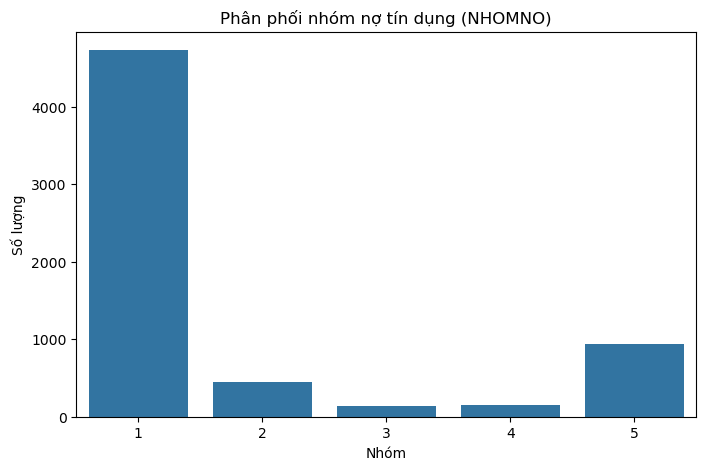

In [136]:
plt.figure(figsize=(8, 5))
sns.countplot(x="NHOMNO", data=df)
plt.title("Phân phối nhóm nợ tín dụng (NHOMNO)")
plt.xlabel("Nhóm")
plt.ylabel("Số lượng")
plt.show()

In [137]:
# Tạo cột target 
df['target'] = np.where(df['NHOMNO'] == 1, 1, 0)

In [138]:
# Handle missing data
df['SEX'].fillna('UNKNOWN', inplace=True)

# Convert dates to datetime
df['OPEN_DATE'] = pd.to_datetime(df['OPEN_DATE'], errors='coerce')
df['NGAYDENHAN'] = pd.to_datetime(df['NGAYDENHAN'], errors='coerce')

# Calculate loan duration
df['LOAN_DURATION'] = (df['NGAYDENHAN'] - df['OPEN_DATE']).dt.days

# Feature engineering
df['LOAN_TO_BALANCE_RATIO'] = df['CURR_BAL'] / df['BASE_BAL']

/var/folders/2w/0ds979vs33z3m70t85hh_cp00000gn/T/ipykernel_43228/3426819144.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['SEX'].fillna('UNKNOWN', inplace=True)


# Data visualization

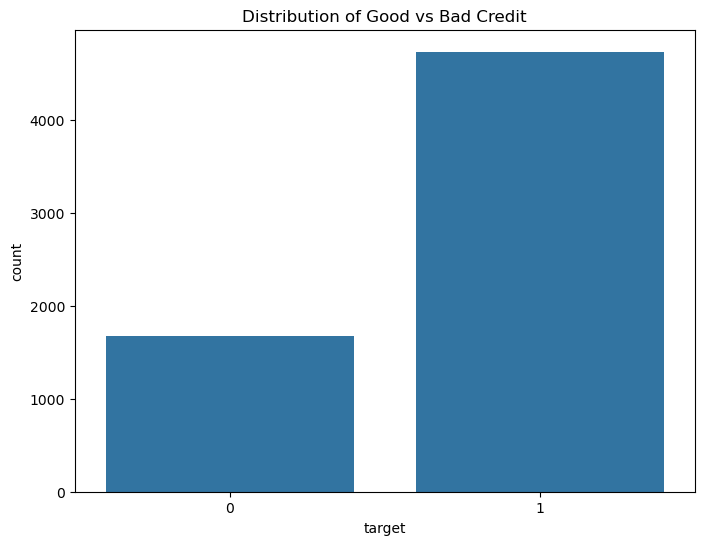

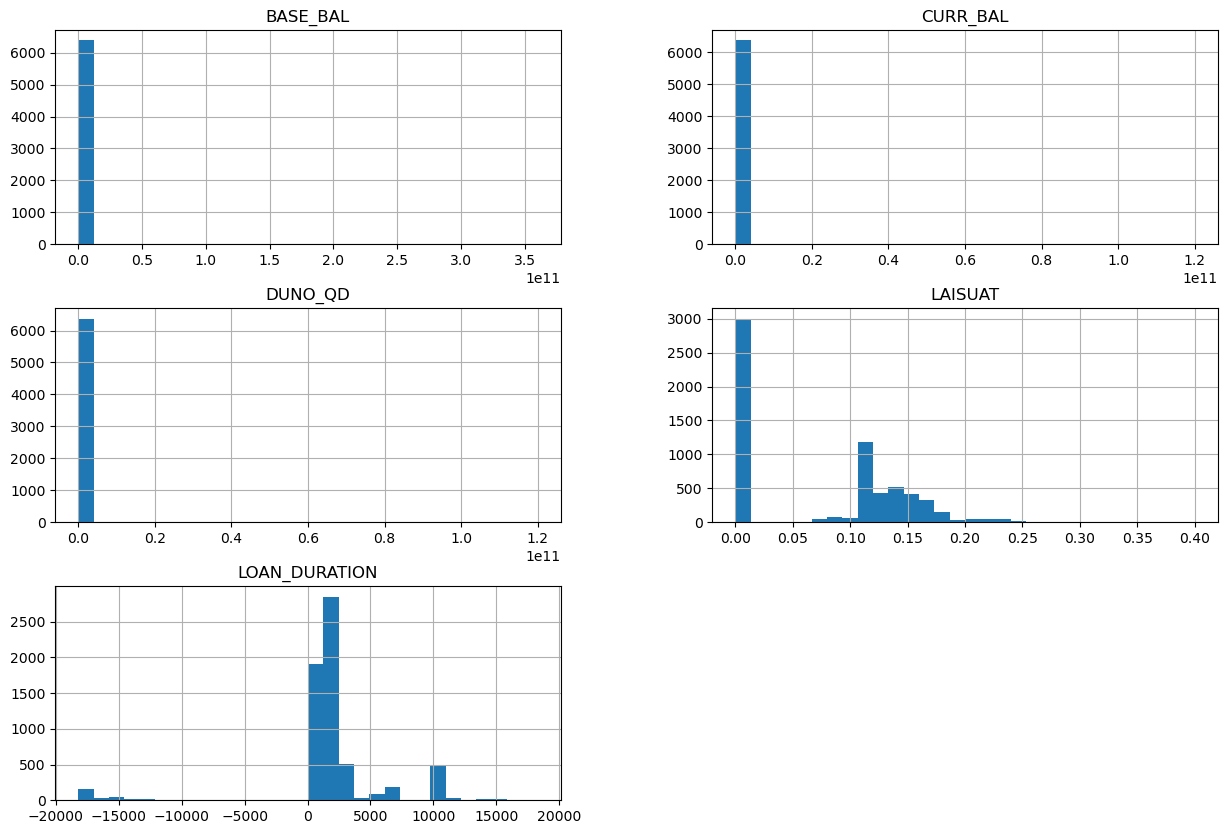

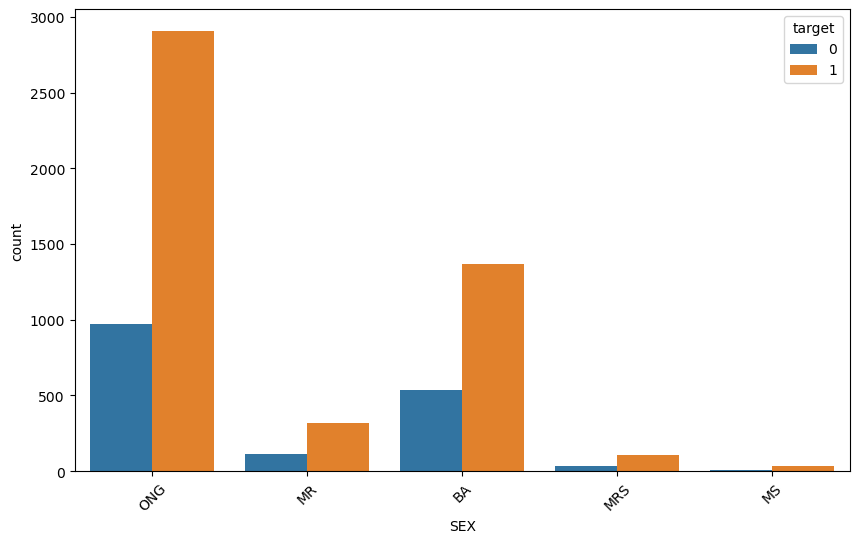

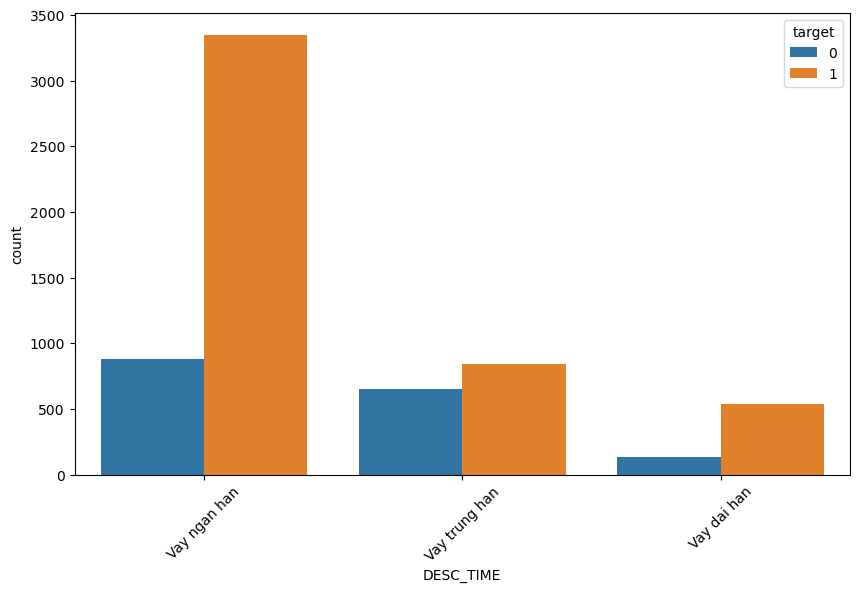

In [139]:
# Target distribution
plt.figure(figsize=(8,6))
sns.countplot(x='target', data=df)
plt.title('Distribution of Good vs Bad Credit')
plt.show()

# Numerical features distribution
num_features = ['BASE_BAL', 'CURR_BAL', 'DUNO_QD', 'LAISUAT', 'LOAN_DURATION']
df[num_features].hist(bins=30, figsize=(15,10))
plt.show()

# Categorical features
cat_features = ['SEX', 'DESC_TIME']
for feature in cat_features:
    plt.figure(figsize=(10,6))
    sns.countplot(x=feature, hue='target', data=df)
    plt.xticks(rotation=45)
    plt.show()

# Correlation Analysis

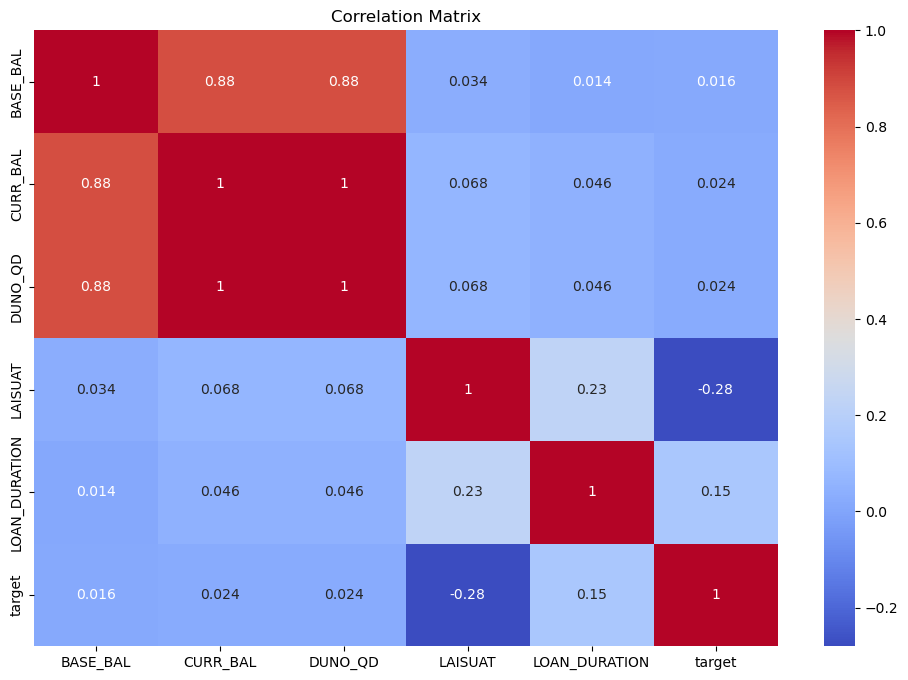

In [140]:
# Correlation matrix
corr_matrix = df[num_features + ['target']].corr()
plt.figure(figsize=(12,8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

# train

In [141]:
X = df[['BASE_BAL', 'CURR_BAL', 'LAISUAT', 'LOAN_DURATION', 'LOAN_TO_BALANCE_RATIO']]
y = df['target']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

print(df.isnull().sum())  # Kiểm tra số lượng giá trị thiếu theo cột
print(df[X.columns].isnull().sum())  # Kiểm tra dữ liệu đầu vào X

df.dropna(inplace=True) # Xoá giá trị NaN

# Train model
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)

# Evaluate
y_pred = lr.predict(X_test)
print(classification_report(y_test, y_pred))
print("ROC AUC:", roc_auc_score(y_test, y_pred))

MJACCTTYPCD              0
PHUONG THUC CHO VAY      0
LOAIKH                   0
SEX                      0
BASE_BAL                 0
CURR_BAL                 0
DUNO_QD                  0
CURRENCYCD               0
OPEN_DATE                0
NGAYDENHAN               0
ID_TIME                  0
DESC_TIME                0
MJACCTTYPDESC            0
ORGNBR                   0
ORGNAME                  0
PARENTORGNBR             0
PARENTORGNAME            0
LAISUAT                  0
MUCDICHVAY               0
NHOMNO                   0
NHOMNOMOI                0
NHOMNO_TCBS              0
target                   0
LOAN_DURATION            0
LOAN_TO_BALANCE_RATIO    0
dtype: int64
BASE_BAL                 0
CURR_BAL                 0
LAISUAT                  0
LOAN_DURATION            0
LOAN_TO_BALANCE_RATIO    0
dtype: int64
              precision    recall  f1-score   support

           0       0.16      0.02      0.04       515
           1       0.73      0.96      0.83      1405



# Data Normalization

In [142]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print(pd.DataFrame(X_train).isnull().sum())  # Kiểm tra lại sau khi chuẩn hóa

0    0
1    0
2    0
3    0
4    0
dtype: int64


# Linear Regression

In [143]:
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [144]:
X = sm.add_constant(X)
model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                 target   R-squared:                       0.127
Model:                            OLS   Adj. R-squared:                  0.127
Method:                 Least Squares   F-statistic:                     186.6
Date:                Wed, 11 Jun 2025   Prob (F-statistic):          4.48e-186
Time:                        20:57:19   Log-Likelihood:                -3377.1
No. Observations:                6399   AIC:                             6766.
Df Residuals:                    6393   BIC:                             6807.
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                            coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------
const                     0.84

# One class

In [145]:
from sklearn.utils.class_weight import compute_class_weight

# Tính trọng số cho từng lớp
class_weights = compute_class_weight(class_weight='balanced', classes=np.unique(y_train), y=y_train)
class_weight_dict = dict(enumerate(class_weights))

# Đưa vào model
logis_model = LogisticRegression(multi_class='multinomial', solver='lbfgs', max_iter=500, class_weight=class_weight_dict)

In [146]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

logis_model.fit(X_train, y_train)

/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1237: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, binary problems will be fit as proper binary  logistic regression models (as if multi_class='ovr' were set). Leave it to its default value to avoid this warning.
  warnings.warn(


LogisticRegression(class_weight={0: 1.9406412478336221, 1: 0.6735338345864662},
                   max_iter=500, multi_class='multinomial')

In [148]:
y_pred = model.predict(X_test)

y_test = y_test.astype(int)
y_pred = y_pred.astype(int)

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("Accuracy:", accuracy_score(y_test, y_pred))


Confusion Matrix:
[[ 515    0]
 [1401    4]]

Classification Report:
              precision    recall  f1-score   support

           0       0.27      1.00      0.42       515
           1       1.00      0.00      0.01      1405

    accuracy                           0.27      1920
   macro avg       0.63      0.50      0.21      1920
weighted avg       0.80      0.27      0.12      1920

Accuracy: 0.2703125


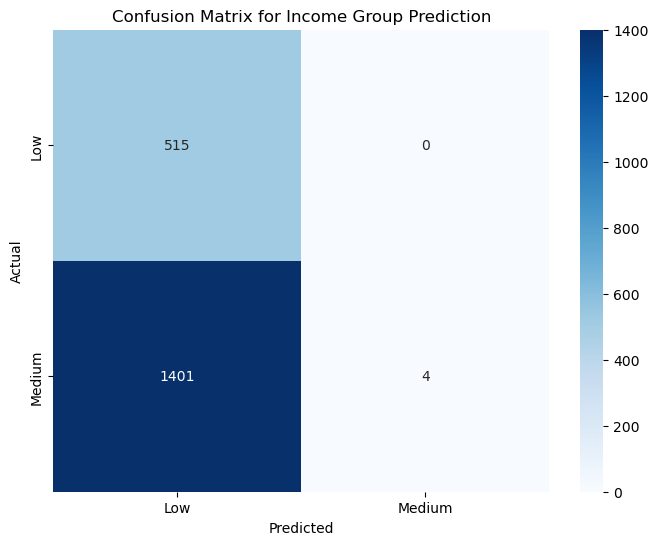

In [149]:
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Low', 'Medium'], 
            yticklabels=['Low', 'Medium'])
plt.title('Confusion Matrix for Income Group Prediction')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Multi-class

# Random Forest

In [150]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
print(classification_report(y_test, y_pred_rf))
print("ROC AUC:", roc_auc_score(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.82      0.63      0.71       515
           1       0.88      0.95      0.91      1405

    accuracy                           0.86      1920
   macro avg       0.85      0.79      0.81      1920
weighted avg       0.86      0.86      0.86      1920

ROC AUC: 0.7899112047818124


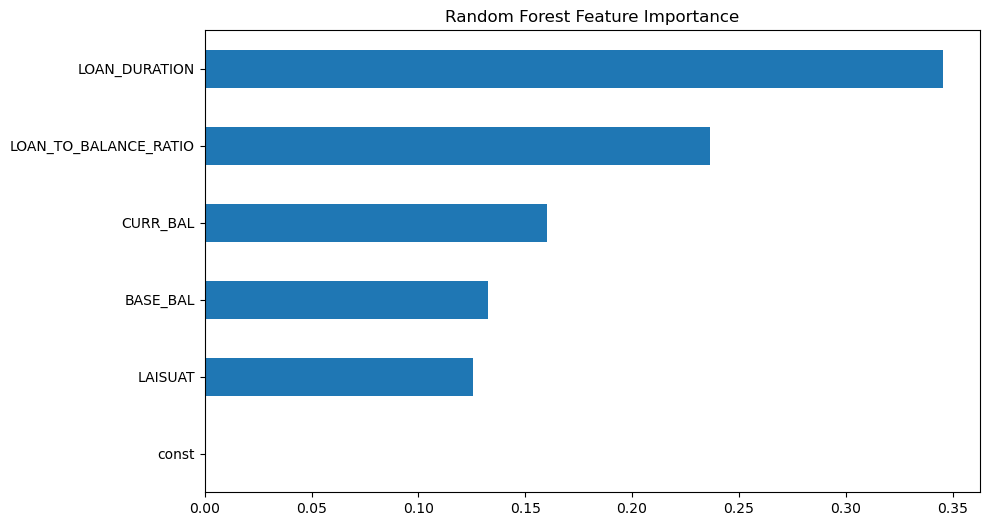

In [151]:
plt.figure(figsize=(10,6))
pd.Series(rf.feature_importances_, index=X.columns).sort_values().plot(kind='barh')
plt.title('Random Forest Feature Importance')
plt.show()

# XGBoost

In [152]:
xgb = XGBClassifier(use_label_encoder=False, eval_metric='logloss')
xgb.fit(X_train, y_train)

y_pred_xgb = xgb.predict(X_test)
print(classification_report(y_test, y_pred_xgb))
print("ROC AUC:", roc_auc_score(y_test, y_pred_xgb))

              precision    recall  f1-score   support

           0       0.85      0.60      0.70       515
           1       0.87      0.96      0.91      1405

    accuracy                           0.86      1920
   macro avg       0.86      0.78      0.81      1920
weighted avg       0.86      0.86      0.86      1920

ROC AUC: 0.7807829181494661


/opt/anaconda3/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [20:57:46] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


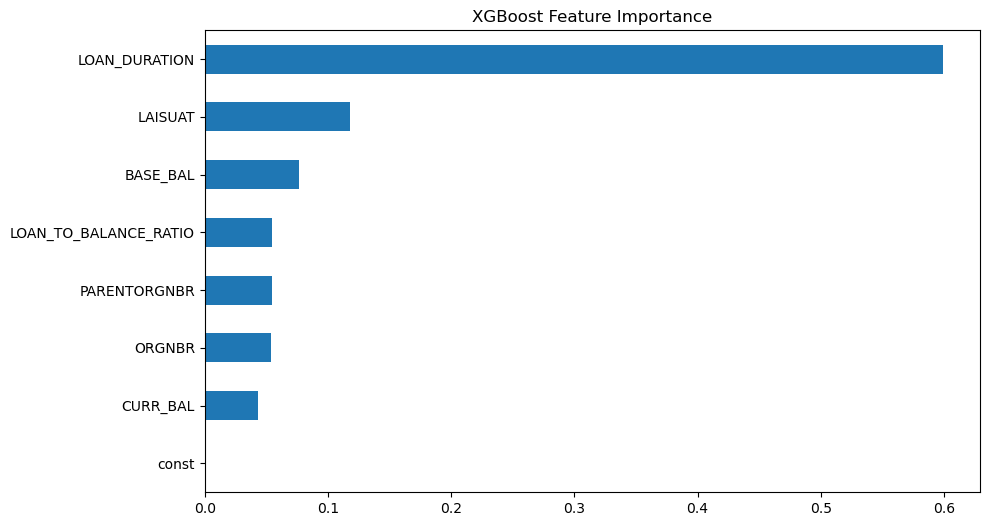

In [ ]:
# Plot feature importance for XGBoost
plt.figure(figsize=(10,6))
pd.Series(xgb.feature_importances_, index=X.columns).sort_values().plot(kind='barh')
plt.title('XGBoost Feature Importance')
plt.show()

In [ ]:
gb_model = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, random_state=42)
gb_model.fit(X_train, y_train)

GradientBoostingClassifier(random_state=42)

In [ ]:
print(gb_model)

GradientBoostingClassifier(random_state=42)


In [ ]:
# 7. Đánh giá hiệu suất mô hình trên tập kiểm thử
models = {
    "Logistic Regression": logis_model,
    
    "Random Forest": rf,
    "Gradient Boosting": gb_model
}

for name, model in models.items():
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    print(f"\n{name} - Đánh giá hiệu suất:")
    print("Accuracy:", np.round(acc, 4))
    print("Classification Report:")
    print(classification_report(y_test, y_pred))
    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred))


Logistic Regression - Đánh giá hiệu suất:
Accuracy: 0.7036
Classification Report:
              precision    recall  f1-score   support

           0       0.14      0.02      0.04       515
           1       0.73      0.95      0.82      1405

    accuracy                           0.70      1920
   macro avg       0.44      0.49      0.43      1920
weighted avg       0.57      0.70      0.61      1920

Confusion Matrix:
[[  11  504]
 [  65 1340]]

Random Forest - Đánh giá hiệu suất:
Accuracy: 0.8776
Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.65      0.74       515
           1       0.88      0.96      0.92      1405

    accuracy                           0.88      1920
   macro avg       0.87      0.80      0.83      1920
weighted avg       0.88      0.88      0.87      1920

Confusion Matrix:
[[ 333  182]
 [  53 1352]]

Gradient Boosting - Đánh giá hiệu suất:
Accuracy: 0.8677
Classification Report:
              p

# Kiểm tra thông tin sơ bộ của dữ liệu
print("Thông tin dataset:")
print(df.info())
print("\nSố lượng giá trị thiếu theo từng cột:")
print(df.isnull().sum())

# 2. Xử lý dữ liệu thiếu 
# Với dữ liệu số, ta có thể điền giá trị trung bình, dữ liệu phân loại sẽ cần phương pháp khác nếu có
numeric_cols = df.select_dtypes(include=["int64", "float64"]).columns
df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].mean())

# Với các biến phân loại (nếu tồn tại), có thể fill bằng mode hoặc xác định thủ công:
categorical_cols = df.select_dtypes(include=["object"]).columns
for col in categorical_cols:
    df[col] = df[col].fillna(df[col].mode()[0])
    
# 4. Mã hóa dữ liệu - chuyển các biến phân loại thành số nếu cần thiết
label_encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le

# Ngoài ra, có thể xem ma trận tương quan để xem mối liên hệ giữa các biến
plt.figure(figsize=(12, 10))
corr = df.corr()
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Ma trận tương quan giữa các đặc trưng")
plt.show()

# 5. Chia dữ liệu thành tập huấn luyện và tập kiểm thử
# Tạo biến target: nhóm 1 được xem là "good" (0) và nhóm 2,3,4,5 là "bad" (1)
# Nếu NHOMNO có giá trị kiểu số, kiểm tra thật cẩn: dưới đây giả định rằng giá trị "1" là good.
df['Target'] = df['NHOMNO'].apply(lambda x: 0 if x == 1 else 1)

# Chọn đặc trưng: ta loại bỏ cột NHOMNO gốc và Target là biến cần dự đoán
X = df.drop(["NHOMNO", "Target"], axis=1)
y = df["Target"]

# Tách dữ liệu thành 80% train và 20% test (có thể set random_state cho tái lập)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Chuẩn hóa dữ liệu cho những mô hình cảm nhạy với độ scale của đặc trưng
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# 6. Huấn luyện các mô hình:
# (a) Mô hình truyền thống: Logistic Regression
log_model = LogisticRegression(max_iter=1000, random_state=42)
log_model.fit(X_train, y_train)

# (b) Mô hình học máy hiện đại: Random Forest
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# (c) Mô hình học máy hiện đại: Gradient Boosting
gb_model = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, random_state=42)
gb_model.fit(X_train, y_train)

# 8. Dự đoán trên tập xác thực
# Trong trường hợp này, dùng tập kiểm thử (X_test) như tập xác thực. Bạn có thể thay đổi nếu có tập validation riêng.
y_val_pred = rf_model.predict(X_test)
# Gán nhãn dự đoán vào dataframe ban đầu (lưu ý: chỉ gán với các mẫu có index tương ứng của tập test)
df_val = df.iloc[X_test.shape[0]*(-1):].copy()  # Lấy tạm những bản ghi cuối của dữ liệu. 
df_val["Predicted_Class"] = y_val_pred




import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, classification_report, roc_curve, auc

# Đọc hai tập dữ liệu (thay đổi đường dẫn file phù hợp)
df1 = pd.read_csv("dataset1.csv")
df2 = pd.read_csv("dataset2.csv")

# Xử lý missing values
df1.fillna(df1.mean(), inplace=True)
df2.fillna(df2.mean(), inplace=True)

# Chuyển NHOMNO thành biến mục tiêu
df1["Target"] = df1["NHOMNO"].apply(lambda x: 0 if x == 1 else 1)
df2["Target"] = df2["NHOMNO"].apply(lambda x: 0 if x == 1 else 1)

# Chọn đặc trưng và chuẩn hóa dữ liệu
features = [col for col in df1.columns if col not in ["NHOMNO", "Target"]]
X1, y1 = df1[features], df1["Target"]
X2, y2 = df2[features], df2["Target"]

scaler = StandardScaler()
X1 = scaler.fit_transform(X1)
X2 = scaler.transform(X2)

# Chia tập train/test
X1_train, X1_test, y1_train, y1_test = train_test_split(X1, y1, test_size=0.2, random_state=42)
X2_train, X2_test, y2_train, y2_test = train_test_split(X2, y2, test_size=0.2, random_state=42)

# Huấn luyện mô hình
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(n_estimators=100),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=100)
}

results = {}

for name, model in models.items():
    model.fit(X1_train, y1_train)
    y1_pred = model.predict(X1_test)
    acc1 = accuracy_score(y1_test, y1_pred)
    
    model.fit(X2_train, y2_train)
    y2_pred = model.predict(X2_test)
    acc2 = accuracy_score(y2_test, y2_pred)
    
    results[name] = {"Dataset 1 Accuracy": acc1, "Dataset 2 Accuracy": acc2}

# Hiển thị kết quả
print("\nSo sánh hiệu suất mô hình trên hai tập dữ liệu:")
print(pd.DataFrame(results))

# Vẽ ROC Curve để so sánh
plt.figure(figsize=(8, 6))
for name, model in models.items():
    y1_prob = model.predict_proba(X1_test)[:, 1]
    y2_prob = model.predict_proba(X2_test)[:, 1]
    
    fpr1, tpr1, _ = roc_curve(y1_test, y1_prob)
    fpr2, tpr2, _ = roc_curve(y2_test, y2_prob)
    
    plt.plot(fpr1, tpr1, label=f'{name} - Dataset 1')
    plt.plot(fpr2, tpr2, label=f'{name} - Dataset 2')

plt.plot([0,1], [0,1], linestyle='--', color='gray')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("So sánh ROC Curve trên 2 tập dữ liệu")
plt.legend()
plt.show()
